### Importing libraries


This file is a Jupyter Notebook, which is a type of interactive development environment for code.

This Python block imports existing Python libraries from your environment, which are pre-written batches of code.

`numpy`: Makes working with arrays easier <br>
`matplotlib.pyplot`: Allows creation of nice graphs and figures<br>
`pathlib`: Makes it easier to interact with files<br>
`xml.etree.ElementTree`: For reading XML

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import xml.etree.ElementTree as et

### Import and arrange data

Whenever saving data from the RTO 2000 scope, there will be two files created for each waveform: one that ends with `.Wfm.bin`, and one that ends with only `.bin`. <br>

> The **actual waveform data** is in the file that ends with `.Wfm.bin`. <br>
> The `.bin` file with the same name is a **metadata file** which contains the oscilloscope parameters at time of waveform capture. 



These are binary files; the content of the file is compressed and won't be helpful if you view it on its own. 

If you open the `.Wfm.bin` file in a text editor, you'll see a jumble of nonsense. 
If you open the `.bin` file, you might be able to make sense of it, but we can make interpretation easier.

------------

We'll start by looking at the `.bin` file. This file contains the metadata for the waveform, or the oscilloscope parameters at the time of capture. <br>
This data file is in Extensible Markup Language (XML), a data-storing format that is both human-readable and machine-readable. 

This code block takes the attributes of each element in the file and makes them into keys in a dictionary. <br>
It reads in the file, determines its structure and holds it in "tree", then determines the "root" of the file (the root holds all the elements.)

Not every element will be of relevance to us, so here are some that might be relevant, now or later: <br>
> `Resolution`, `SignalResolution`: Tells you the time spacing between data points. The smaller, the better!<br>
> `TriggerOffset`: The time difference between the designated trigger event and the center of the oscilloscope's display <br>
> `Impedance`: The resistance necessary to prevent the signal reflecting in the wire and contaminating the waveform. <br>
> `TimeScale`: Tells you the spacing of the oscilloscope x-axis tick marks (time) displayed at time of capture. <br>
> `VerticalScale`: Tells you the spacing of the oscilloscope y-axis tick marks (voltage) displayed at time of capture. <br>
> `InterpolationMode`: States how the waveform was mathematically constructed. <br>
> `VerticalOffset`: How much voltage the waveform is shifted up or down by on the oscilloscope display at time of capture. <br>
> `XStart`: What time before the trigger event the scope started recording data

In [4]:
n = 2
file_name = f"EB_PMT_{n}_AVG50_09_22_2026"

metadata_path = Path(f"C:/Users/ariel/Research/NOPTREX_LLUR/intro_signal_analysis/{file_name}.bin") # change this based on your own file directory. 
tree = et.parse(metadata_path)
root = tree.getroot()

metadata = {}

for prop in root.iter("Prop"):
    metadata[prop.get("Name")] = prop.get("Value")

# print a list of all the keys
# print(list(metadata.keys())) 

# print the keys and the values they hold
for prop in root.iter("Prop"):
    name = prop.get("Name")
    value = prop.get("Value")
    print(f"{name}: {value}")

# if you want to access a specfic value: metadata["ElementName"]
# where ElementName is the key/value/information you want to access
# print(metadata["Resolution"])

SourceType: eRS_SIGNAL_SOURCE_TYPE_SOURCE
Resolution: 1e-11
RecordLength: 5000
HWRecordLength: 5000
TriggerOffset: 0
RescaleCenterTime: -8.71e-09
DecimationMode: eRS_DECIMATION_MODE_SAMPLE
TraceArithmetics: eRS_TRACE_ARITHMETICS_AVERAGE
TraceType: eRS_TRACE_TYPE_AVERAGE
BaseUnit: eRS_UNIT_LEVEL_V
BaseUnitRelative: eRS_ONOFF_OFF
Impedance: 50
XStart: -3.374e-08
XStop: 1.626e-08
SignalRecordLength: 5000
HardwareXStart: -3.374e-08
HardwareXStop: 1.626e-08
SignalHardwareRecordLength: 5000
AdjustedResolutionBW: 0
NoiseBandwidth: 0
InterleavedTraceCount: 1
ValueType: eRS_SIGNAL_VALUE_TYPE_COMPLETELY_FINITE_DEFINED
NofQuantisationLevels: 16580608
DecimationFactor: 1
TOADone: eRS_ONOFF_ON
ISO_TRG: 0
SC_POST: 0
SC_TRG: 0
SignalResolution: 1e-11
LeadingSettlingSamples: 0
TimeScale: 5e-09
ReferencePoint: 67.47
RescaleCenterPoint: 50.05
VerticalPosition: 0
VerticalScale: 0.2
VerticalOffset: -0.389
BaseYStart: -1.389
BaseYStop: 0.611
ViewUnit: eRS_UNIT_LEVEL_V
ViewUnitRelative: eRS_ONOFF_OFF
ViewRe

Next, we'll read in the `.Wfm.bin` file.
The file path is declared, read in, and stored in `practice_data`.
The data is a 1D array, which holds the voltage values of each data point.

In [7]:
file_path = Path(f"C:/Users/ariel/Research/NOPTREX_LLUR/intro_signal_analysis/{file_name}.Wfm.bin")
practice_data = np.fromfile(file_path, dtype = np.float32)

### Plotting/interpreting the data

We need to scale the data by the scaling that the oscilloscope was set to at the time of capture; this info is stored in `metadata["VerticalScale"]`.

Each point in `practice_data` in a voltage point in time; so to graph the waveform, we need the time that goes with the voltage. <br>
We can get that by making an array that is the same size as `practice_data`, and scaling it by the time resolution (`metadata['SignalResolution]`). <br>
Then, we need to know how long before the trigger point the scope started recording; this is stored in `metadata[XStart]`, and is added to the time.

In [8]:
practice_waveform = practice_data * float(metadata["VerticalScale"]) + float(metadata["VerticalOffset"])
t = float(metadata["XStart"]) + np.arange(len(practice_waveform)) * float(metadata["SignalResolution"])

Next, graphing.

Text(0, 0.5, 'Voltage [mV]')

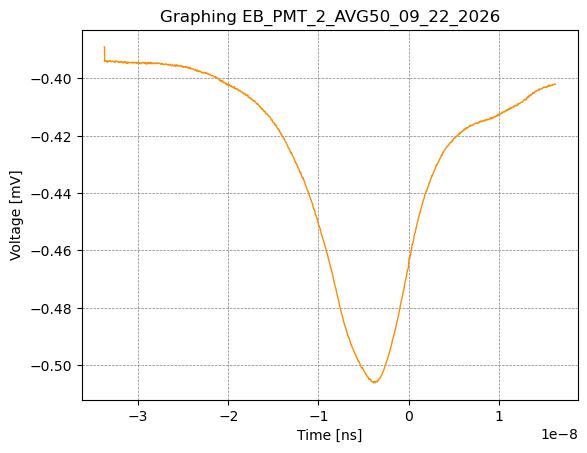

In [9]:
fig, ax = plt.subplots()
ax.plot(t, practice_waveform, color = "darkorange", lw = 1)
ax.grid(color='gray', linestyle='--', linewidth=0.5)
ax.set_title(f"Graphing {file_name}")

ax.set_xlabel("Time [ns]")
ax.set_ylabel("Voltage [mV]")
